# ExpectiminimaxAgent2: debugging testbench

Simple play between Expectiminimax2 and Greedy. Used for debugging and profiling.

In [19]:
import cProfile
import time

from nb_setup import risk_ai_game

EM2_MAX_DEPTH = 3
EM2_TOP_K = 3
RANDOM_SEED = 5678
MAX_TURNS = 500
PROFILE = True

#OPPONENT_CLS = risk_ai_game.RandomAgent
OPPONENT_CLS = risk_ai_game.GreedyAgent


class DurationTelemetry(risk_ai_game.GameTelemetry):
    def __init__(self):
        self.duration_seconds = None
        self._t0 = None

    def on_game_start(self, game_state):
        self._t0 = time.perf_counter()

    def on_before_action(self, game_state):
        pass

    def on_action(self, game_state, action, result):
        pass

    def on_game_end(self, game_state, winner):
        if self._t0 is not None:
            self.duration_seconds = time.perf_counter() - self._t0


def run_one_game(telemetry):
    if OPPONENT_CLS is risk_ai_game.RandomAgent:
        opponent = OPPONENT_CLS(0, aggression=0.5, name="P0-Random")
    else:
        opponent = OPPONENT_CLS(0, name="P0-Greedy")
    em2 = risk_ai_game.ExpectiminimaxAgent2(
        1,
        max_depth=EM2_MAX_DEPTH,
        top_k=EM2_TOP_K,
        name="P1-EM2",
    )
    agents = [opponent, em2]
    opts = risk_ai_game.RiskAIGameOptions(
        agents=agents,
        max_turns=MAX_TURNS,
        verbose=False,
        random_seed=RANDOM_SEED,
        game_telemetry=telemetry,
    )
    return risk_ai_game.run_game(opts)


telemetry = DurationTelemetry()
if PROFILE:
    pr = cProfile.Profile()
    winner = pr.runcall(run_one_game, telemetry)
    pr.print_stats(sort="cumtime")
else:
    winner = run_one_game(telemetry)

print(telemetry.duration_seconds)
print(winner)

         1803792 function calls (1779480 primitive calls) in 1.483 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    11273    0.011    0.000    0.441    0.000 expectiminimax_agent_2.py:420(_copy_state)
    11273    0.297    0.000    0.425    0.000 board.py:57(copy_state)
     2619    0.014    0.000    0.362    0.000 greedy_agent.py:15(choose_action)
      262    0.011    0.000    0.315    0.001 expectiminimax_agent_2.py:241(_generate_fortify_actions)
     2080    0.042    0.000    0.285    0.000 expectiminimax_agent_2.py:207(_generate_attack_actions)
    20503    0.031    0.000    0.198    0.000 game_state.py:232(get_winner)
    46311    0.134    0.000    0.185    0.000 game_state.py:36(get_player_territories)
   360223    0.115    0.000    0.182    0.000 board.py:54(get)
      275    0.013    0.000    0.173    0.001 greedy_agent.py:108(_choose_fortify)
     8976    0.011    0.000    0.172    0.000 expectiminimax_agent_

Depth=1, Top K=1, Win Rate=0.480, Mean Time/Phase=0.000158s
Depth=1, Top K=2, Win Rate=0.490, Mean Time/Phase=0.000250s
Depth=1, Top K=3, Win Rate=0.460, Mean Time/Phase=0.000255s
Depth=1, Top K=4, Win Rate=0.490, Mean Time/Phase=0.000255s
Depth=3, Top K=1, Win Rate=0.480, Mean Time/Phase=0.000417s
Depth=3, Top K=2, Win Rate=0.510, Mean Time/Phase=0.001915s
Depth=3, Top K=3, Win Rate=0.550, Mean Time/Phase=0.004557s
Depth=3, Top K=4, Win Rate=0.510, Mean Time/Phase=0.007485s
Depth=5, Top K=1, Win Rate=0.480, Mean Time/Phase=0.001322s
Depth=5, Top K=2, Win Rate=0.550, Mean Time/Phase=0.022080s
Depth=5, Top K=3, Win Rate=0.540, Mean Time/Phase=0.101933s
Depth=5, Top K=4, Win Rate=0.530, Mean Time/Phase=0.281179s


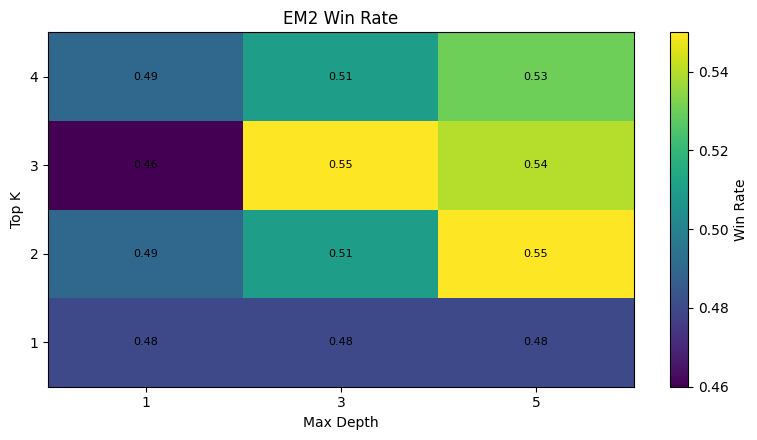

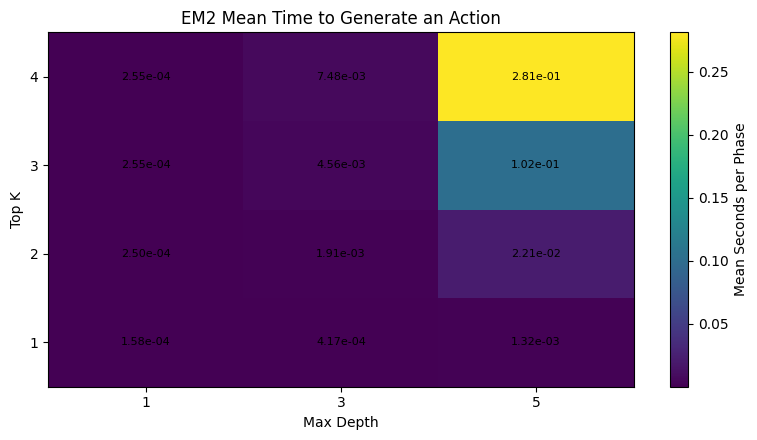

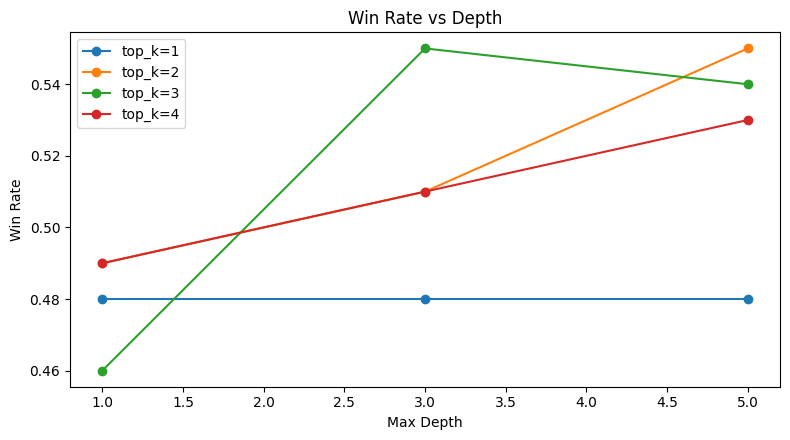

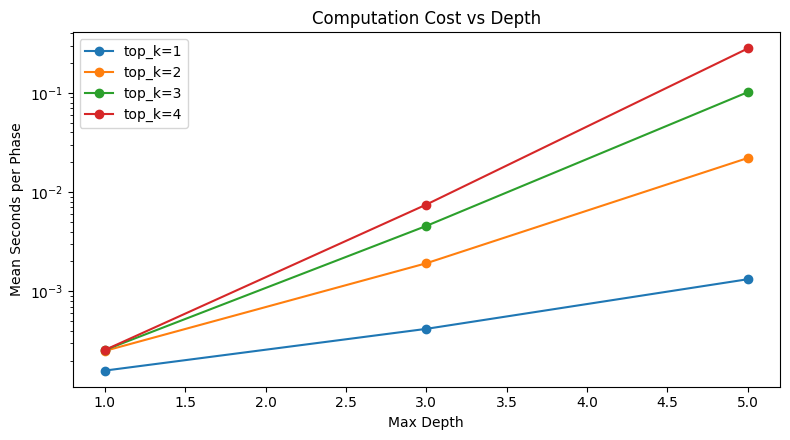

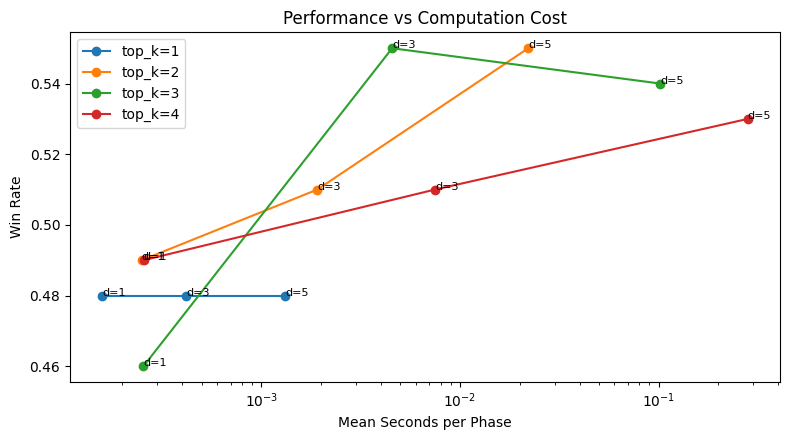

In [20]:
import time
import csv
import math
import matplotlib.pyplot as plt

from nb_setup import risk_ai_game

EM2_MAX_DEPTH = [1, 3, 5]
EM2_TOP_K = [1, 2, 3, 4]
RANDOM_SEED = 5678
MAX_TURNS = 500
NUM_GAMES = 100

OPPONENT_CLS = risk_ai_game.GreedyAgent


class DurationTelemetry(risk_ai_game.GameTelemetry):
    def __init__(self):
        self.total_action_seconds = 0.0
        self.num_phases = 0
        self._t0 = None

    def on_game_start(self, game_state):
        pass

    def on_before_action(self, game_state):
        self._t0 = time.perf_counter()

    def on_action(self, game_state, action, result):
        if self._t0 is not None:
            self.total_action_seconds += time.perf_counter() - self._t0
            self.num_phases += 1
            self._t0 = None

    def on_game_end(self, game_state, winner):
        pass


def make_agents(i, depth, top_k):
    em2_first = (i % 2 == 1)

    if em2_first:
        em2_player_id = 0
        opp_player_id = 1
    else:
        opp_player_id = 0
        em2_player_id = 1

    if OPPONENT_CLS is risk_ai_game.RandomAgent:
        opponent = OPPONENT_CLS(
            opp_player_id,
            aggression=0.5,
            name=f"P{opp_player_id}-Random",
        )
    else:
        opponent = OPPONENT_CLS(
            opp_player_id,
            name=f"P{opp_player_id}-Greedy",
        )

    em2 = risk_ai_game.ExpectiminimaxAgent2(
        em2_player_id,
        max_depth=depth,
        top_k=top_k,
        name=f"P{em2_player_id}-EM2",
    )

    agents = [None, None]
    agents[opp_player_id] = opponent
    agents[em2_player_id] = em2

    return agents, em2_player_id


def run_one_game(telemetry, depth, top_k, i):
    agents, em2_player_id = make_agents(i, depth, top_k)

    opts = risk_ai_game.RiskAIGameOptions(
        agents=agents,
        max_turns=MAX_TURNS,
        verbose=False,
        random_seed=RANDOM_SEED + i,
        game_telemetry=telemetry,
    )

    winner = risk_ai_game.run_game(opts)
    return winner, em2_player_id


# Store results in a dict keyed by (depth, top_k)
results = {}

# save incrementally so a late plotting failure doesn't lose the experiment
csv_path = "em2_grid_results.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "depth",
        "top_k",
        "win_rate",
        "mean_time_per_phase",
        "total_action_seconds",
        "num_phases",
        "num_games",
    ])

    for depth in EM2_MAX_DEPTH:
        for top_k in EM2_TOP_K:
            telemetry = DurationTelemetry()
            em2_wins = 0

            for i in range(NUM_GAMES):
                winner, em2_player_id = run_one_game(telemetry, depth, top_k, i)
                if winner == em2_player_id:
                    em2_wins += 1

            win_rate = em2_wins / NUM_GAMES
            mean_time = (
                telemetry.total_action_seconds / telemetry.num_phases
                if telemetry.num_phases > 0 else float("nan")
            )

            results[(depth, top_k)] = {
                "win_rate": win_rate,
                "mean_time_per_phase": mean_time,
                "total_action_seconds": telemetry.total_action_seconds,
                "num_phases": telemetry.num_phases,
            }

            writer.writerow([
                depth,
                top_k,
                win_rate,
                mean_time,
                telemetry.total_action_seconds,
                telemetry.num_phases,
                NUM_GAMES,
            ])
            f.flush()

            print(
                f"Depth={depth}, Top K={top_k}, "
                f"Win Rate={win_rate:.3f}, "
                f"Mean Time/Phase={mean_time:.6f}s"
            )


# Build 2D matrices: rows = top_k, cols = depth
win_rate_grid = [
    [results[(depth, top_k)]["win_rate"] for depth in EM2_MAX_DEPTH]
    for top_k in EM2_TOP_K
]

time_grid = [
    [results[(depth, top_k)]["mean_time_per_phase"] for depth in EM2_MAX_DEPTH]
    for top_k in EM2_TOP_K
]


# Heatmap: win rate
plt.figure(figsize=(8, 4.5))
plt.imshow(win_rate_grid, aspect="auto", origin="lower")
plt.colorbar(label="Win Rate")
plt.xticks(range(len(EM2_MAX_DEPTH)), EM2_MAX_DEPTH)
plt.yticks(range(len(EM2_TOP_K)), EM2_TOP_K)
plt.xlabel("Max Depth")
plt.ylabel("Top K")
plt.title("EM2 Win Rate")
for r, top_k in enumerate(EM2_TOP_K):
    for c, depth in enumerate(EM2_MAX_DEPTH):
        plt.text(c, r, f"{win_rate_grid[r][c]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()


# Heatmap: mean time per phase (log10 seconds shown as text)
plt.figure(figsize=(8, 4.5))
plt.imshow(time_grid, aspect="auto", origin="lower")
plt.colorbar(label="Mean Seconds per Phase")
plt.xticks(range(len(EM2_MAX_DEPTH)), EM2_MAX_DEPTH)
plt.yticks(range(len(EM2_TOP_K)), EM2_TOP_K)
plt.xlabel("Max Depth")
plt.ylabel("Top K")
plt.title("EM2 Mean Time to Generate an Action")
for r, top_k in enumerate(EM2_TOP_K):
    for c, depth in enumerate(EM2_MAX_DEPTH):
        plt.text(c, r, f"{time_grid[r][c]:.2e}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()


# Win rate vs depth, one line per top_k
plt.figure(figsize=(8, 4.5))
for top_k in EM2_TOP_K:
    ys = [results[(depth, top_k)]["win_rate"] for depth in EM2_MAX_DEPTH]
    plt.plot(EM2_MAX_DEPTH, ys, marker="o", label=f"top_k={top_k}")
plt.xlabel("Max Depth")
plt.ylabel("Win Rate")
plt.title("Win Rate vs Depth")
plt.legend()
plt.tight_layout()
plt.show()


# Mean time vs depth, one line per top_k
plt.figure(figsize=(8, 4.5))
for top_k in EM2_TOP_K:
    ys = [results[(depth, top_k)]["mean_time_per_phase"] for depth in EM2_MAX_DEPTH]
    plt.plot(EM2_MAX_DEPTH, ys, marker="o", label=f"top_k={top_k}")
plt.yscale("log")
plt.xlabel("Max Depth")
plt.ylabel("Mean Seconds per Phase")
plt.title("Computation Cost vs Depth")
plt.legend()
plt.tight_layout()
plt.show()


# Performance vs computation cost
plt.figure(figsize=(8, 4.5))
for top_k in EM2_TOP_K:
    xs = [results[(depth, top_k)]["mean_time_per_phase"] for depth in EM2_MAX_DEPTH]
    ys = [results[(depth, top_k)]["win_rate"] for depth in EM2_MAX_DEPTH]
    plt.plot(xs, ys, marker="o", label=f"top_k={top_k}")
    for depth, x, y in zip(EM2_MAX_DEPTH, xs, ys):
        plt.text(x, y, f"d={depth}", fontsize=8)
plt.xscale("log")
plt.xlabel("Mean Seconds per Phase")
plt.ylabel("Win Rate")
plt.title("Performance vs Computation Cost")
plt.legend()
plt.tight_layout()
plt.show()

# Expectiminimax2: Simple Performance Profile

These measurements were taken by using a modified version of the tournament notebook.

Since depth values of 6, 7, 8 currently take too long to process, it's not practical to automate them until significant performance improvments are made.

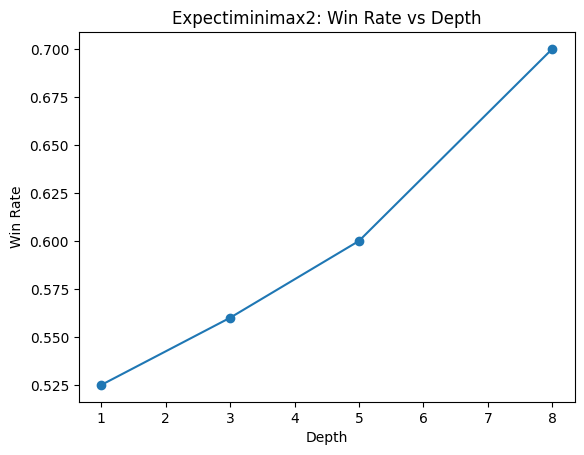

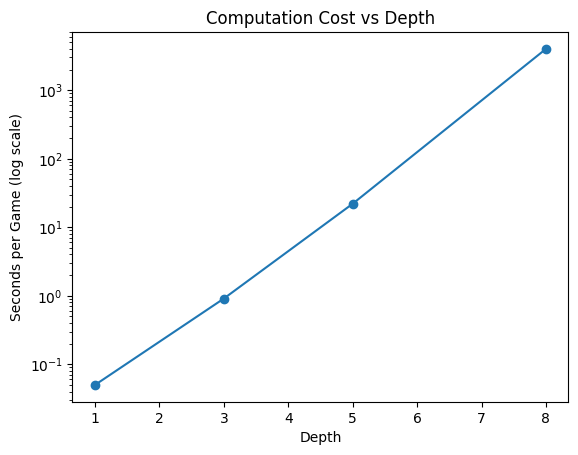

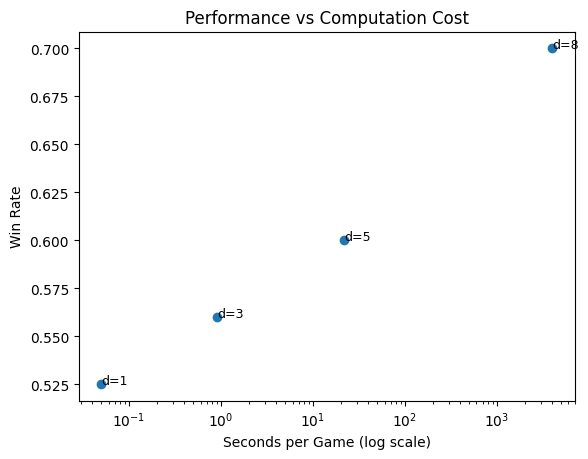

In [22]:
import matplotlib.pyplot as plt

# this is hand captured data as when we hit depth = 8, it takes forever to run.
data = [
    {"depth": 8, "win_rate": 0.70, "sec_per_game": 3996.0},
    {"depth": 5, "win_rate": 0.60, "sec_per_game": 22.0},
    {"depth": 3, "win_rate": 0.56, "sec_per_game": 0.91},
    {"depth": 1, "win_rate": 0.525, "sec_per_game": 0.05},
]

# sort by depth
data = sorted(data, key=lambda x: x["depth"])

# unpack into lists
depths = [d["depth"] for d in data]
win_rates = [d["win_rate"] for d in data]
times = [d["sec_per_game"] for d in data]

plt.figure()
plt.plot(depths, win_rates, marker='o')
plt.xlabel("Depth")
plt.ylabel("Win Rate")
plt.title("Expectiminimax2: Win Rate vs Depth")
plt.show()

plt.figure()
plt.plot(depths, times, marker='o')
plt.yscale("log")  # important
plt.xlabel("Depth")
plt.ylabel("Seconds per Game (log scale)")
plt.title("Computation Cost vs Depth")
plt.show()

plt.figure()
plt.scatter(times, win_rates)
for d, t, w in zip(depths, times, win_rates):
    plt.text(t, w, f"d={d}", fontsize=9)
plt.xscale("log")
plt.xlabel("Seconds per Game (log scale)")
plt.ylabel("Win Rate")
plt.title("Performance vs Computation Cost")

plt.show()